<center> </center>

<center><font size=5 face="Helvetica" color=#306998><b>
Legume Test: Band Strcture with Q factor of a Square PhC Slab
</b></font></center>

<center><font face="Helvetica" size=3><b>Ang Chen</b></font></center>
<center><font face="Helvetica" size=3>February, 2025</font></center>

***

In [1]:
import legume
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Helvetica"
%matplotlib inline
%config InlineBackend.figure_format='svg'


# Band Structure Calculations of a Square PhC Slab

## Parameters of the symmetric square PhC slab

In [ ]:
n_Si3N4 = 2.02
n_SiO2 = 1.46
a = 336.

d_Si3N4 = 180./a
r = 80./a
eps_c = n_SiO2**2
eps_b = n_Si3N4**2
eps_lower, eps_upper = n_SiO2**2, n_SiO2**2

In [3]:
lattice = legume.Lattice('square')
phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)
phc.add_layer(d=d_Si3N4, eps_b=eps_b)
phc.layers[-1].add_shape(legume.Circle(eps=eps_c, r=r, x_cent=0., y_cent=0))

gme = legume.GuidedModeExp(phc, gmax=5.2, truncate_g='abs')
npw = np.shape(gme.gvec)[1]  # number of plane waves in the expansion
print('Number of reciprocal lattice vectors in the expansion: npw = ', npw)

Number of reciprocal lattice vectors in the expansion: npw =  89


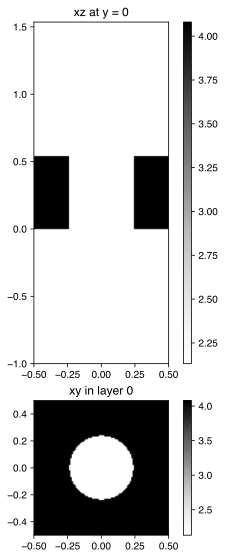

In [4]:
# Visualize what we built
legume.viz.structure(phc, xz=True, xy=True, figsize=3, Nz=300)

## Calculation of bands with the GME method in legume

In [ ]:
# Run the guided-mode expansion
numeig, verbose = 11, True
nk = 120
path = lattice.bz_path(['M', 'G', 'X'], [nk])

gme.run(kpoints=path['kpoints'], angles=path['angles'], gmode_inds=[
        0, 1, 2, 3], numeig=numeig, verbose=True, kz_symmetry='both')
freqs = gme.freqs

nkappa, nfreq = freqs.shape[0], freqs.shape[1]
print(f'Number of wavevectros = {nkappa}, number of frequencies = {nfreq}')

23.969s total time for real part of frequencies in GuidedModeExp, of which
  7.965s (33%) for guided modes computation using the gmode_compute='exact' method
  0.001s (0%) for inverse matrix of Fourier-space permittivity
  9.284s (39%) for matrix diagionalization using the 'eigh' solver
  3.977s (17%) for creating GME matrix
  2.641s (11%) for creating change of basis matrix and multiply it using dense matrices
9.052s  total time for imaginary part of frequencies███████│ 241 of 241
Number of wavevectros = 241, number of frequencies = 11


## Plot all the bands

### Default plot with legume

In [ ]:
# Plot the band structure with Q factors
def plot_bands_Q(gme):
    _, ax = plt.subplots(1, figsize=(10, 6))
    legume.viz.bands(gme, Q=True, ax=ax, cone=True, k_units=True, conecolor='lightgray',
                     markersize=2.5, markeredgecolor='none', markeredgewidth=0)
    ax.set_xticks(path['k_indexes'])
    ax.set_xticklabels(path['labels'])
    ax.xaxis.grid('True')
    ax.set_ylim([0., 0.7])

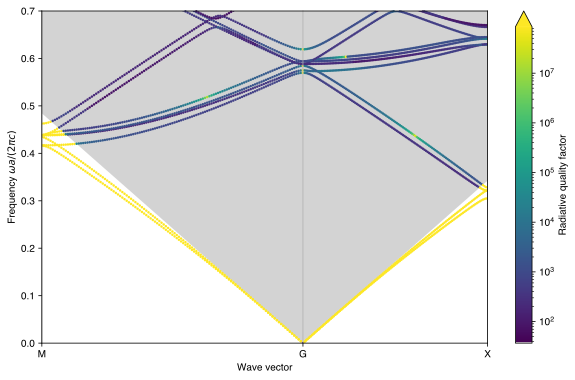

In [7]:
plot_bands_Q(gme)

### Default plot with legume with kz symmetry
In `legume`, $k_z$ symmetry is defined by a vertical plane formed by the mode parallel wave vector $\hat{\textbf{g}}$ and $\hat{z}$, which is different from the definition of conventional `TE-like` and `TM-like` modes.

In [ ]:
def plot_bands_kz(gme):
    """
    Plot the band structure with kz symmetry defined by legume

    Args:
        gme: legume.GuidedModeExp object after running the expansion with kz_symmetry='both'
    """
    fig, ax = plt.subplots(1, figsize=(8, 6))

    freqs = np.asarray(gme.freqs, dtype=float)
    kz_symms = np.asarray(gme.kz_symms, dtype=int)
    k_points = np.asarray(path['kpoints'], dtype=float)

    step_lengths = np.linalg.norm(np.diff(k_points, axis=1), axis=0)
    x_plot = np.concatenate(([0.0], np.cumsum(step_lengths)))
    x_points = np.broadcast_to(x_plot[:, None], freqs.shape)

    k_parallel = np.linalg.norm(k_points, axis=0) / (2 * np.pi)
    light_line = k_parallel / n_SiO2
    gamma_index = int(np.argmin(k_parallel))

    ax.fill_between(x_plot, light_line, np.nanmax(
        freqs), facecolor='#F0EFA6', alpha=0.5)
    ax.scatter(
        x_points[kz_symms == -1],
        freqs[kz_symms == -1],
        s=2,
        c='red',
        linewidths=0,
        label=r'$\sigma_z$ = -1',
    )
    ax.scatter(
        x_points[kz_symms == +1],
        freqs[kz_symms == +1],
        s=2,
        c='blue',
        linewidths=0,
        label=r'$\sigma_z$ = +1',
    )

    tick_locs = [x_plot[0], x_plot[gamma_index], x_plot[-1]]
    tick_labs = ['M', r'$\Gamma$', 'X']
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labs)
    ax.xaxis.grid(True)
    ax.set_xlim([x_plot[0], x_plot[-1]])
    ax.set_ylim([0.0, 0.7])
    ax.set_xlabel('Wave vector')
    ax.set_ylabel(r'Frequency $\omega a/2\pi c$')
    ax.legend(loc='best')
    fig.tight_layout()

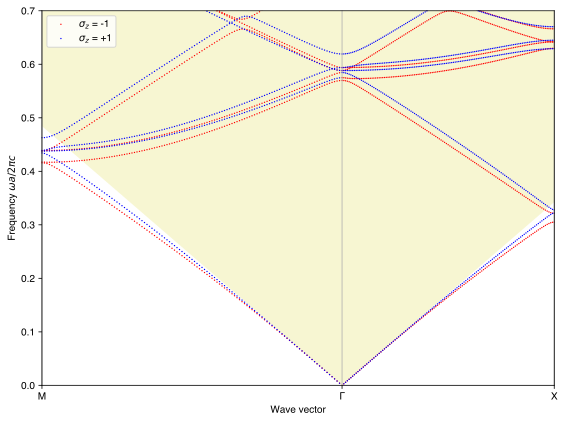

In [9]:
plot_bands_kz(gme)

### Plot with conventional TE-like and TM-like modes

Classify the modes with a benchmark-style quasi-TE / quasi-TM rule.

For this mirror-symmetric slab, the benchmark convention is the slab-plane symmetry with respect to $z \to -z$:
 - quasi-TE: the in-plane electric field dominates at the slab mid-plane, so $E_z(z=0)$ is strongly suppressed
 - quasi-TM: the out-of-plane electric field dominates at the slab mid-plane, so $E_z(z=0)$ remains finite

We therefore use the mid-plane electric-field content, not `kz_symms`, to assign quasi-TE / quasi-TM labels.

In [ ]:
def compute_midplane_tm_fraction(gme, z=0.0):
    # For a mirror-symmetric slab, quasi-TE / quasi-TM can be distinguished
    # from the electric-field content at the slab mid-plane z = 0.
    # quasi-TE: Ez(z=0) is suppressed
    # quasi-TM: Ez(z=0) remains finite
    freqs = np.asarray(gme.freqs, dtype=float)
    tm_fraction = np.full(freqs.shape, np.nan)

    for kind in range(freqs.shape[0]):
        for mind in range(freqs.shape[1]):
            ex_ft, ey_ft, ez_ft = gme.ft_field_xy('E', kind, mind, z)
            ex_power = float(np.sum(np.abs(ex_ft) ** 2))
            ey_power = float(np.sum(np.abs(ey_ft) ** 2))
            ez_power = float(np.sum(np.abs(ez_ft) ** 2))
            total_power = ex_power + ey_power + ez_power

            if total_power > 0:
                tm_fraction[kind, mind] = ez_power / total_power

    return tm_fraction


def classify_modes_by_quasi_polarization(freqs, tm_fraction, tm_threshold=0.1):
    # Store the raw eigenfrequencies in quasi-polarization-resolved arrays.
    # Rows: k-points along M-Gamma-X.
    # Columns: frequency-sorted modes of the chosen quasi-polarization at that k-point.
    tm_mask = np.isfinite(freqs) & np.isfinite(
        tm_fraction) & (tm_fraction >= tm_threshold)
    te_mask = np.isfinite(freqs) & np.isfinite(
        tm_fraction) & (tm_fraction < tm_threshold)

    max_tm = int(np.max(np.sum(tm_mask, axis=1)))
    max_te = int(np.max(np.sum(te_mask, axis=1)))
    tm_like_modes = np.full((freqs.shape[0], max_tm), np.nan)
    te_like_modes = np.full((freqs.shape[0], max_te), np.nan)

    for idx in range(freqs.shape[0]):
        tm_modes = np.sort(freqs[idx, tm_mask[idx]])
        te_modes = np.sort(freqs[idx, te_mask[idx]])
        tm_like_modes[idx, : len(tm_modes)] = tm_modes
        te_like_modes[idx, : len(te_modes)] = te_modes

    return tm_like_modes, te_like_modes


def predicted_value(band, idx, direction):
    if direction > 0:
        valid = np.flatnonzero(np.isfinite(band[:idx]))
        if len(valid) >= 2:
            i1, i0 = valid[-1], valid[-2]
            return band[i1] + (band[i1] - band[i0]) * (idx - i1) / (i1 - i0)
        if len(valid) == 1:
            return band[valid[-1]]
    else:
        valid = np.flatnonzero(np.isfinite(band[idx + 1:])) + idx + 1
        if len(valid) >= 2:
            i1, i0 = valid[0], valid[1]
            return band[i1] + (band[i1] - band[i0]) * (idx - i1) / (i1 - i0)
        if len(valid) == 1:
            return band[valid[0]]

    return np.nan


def extract_all_bands(mode_array, max_jump=0.08):
    # Extract every smooth branch by repeatedly seeding from the leftmost
    # still-unassigned mode, then following it in both directions.
    remaining_modes = mode_array.copy()
    bands = []

    while np.isfinite(remaining_modes).any():
        seed_idx, seed_col = np.argwhere(np.isfinite(remaining_modes))[0]
        seed_idx = int(seed_idx)
        seed_col = int(seed_col)
        seed_freq = float(remaining_modes[seed_idx, seed_col])

        band = np.full(remaining_modes.shape[0], np.nan)
        band[seed_idx] = seed_freq
        remaining_modes[seed_idx, seed_col] = np.nan

        for direction in (+1, -1):
            if direction > 0:
                iterator = range(seed_idx + 1, remaining_modes.shape[0])
            else:
                iterator = range(seed_idx - 1, -1, -1)

            for idx in iterator:
                col_ids = np.flatnonzero(np.isfinite(remaining_modes[idx]))
                modes = remaining_modes[idx, col_ids]
                if len(modes) == 0:
                    continue

                pred = predicted_value(band, idx, direction)
                if not np.isfinite(pred):
                    prev_idx = idx - direction
                    if 0 <= prev_idx < band.size and np.isfinite(band[prev_idx]):
                        pred = band[prev_idx]
                    else:
                        pred = modes[0]

                best = int(np.argmin(np.abs(modes - pred)))
                if np.abs(modes[best] - pred) <= max_jump:
                    band[idx] = modes[best]
                    remaining_modes[idx, col_ids[best]] = np.nan

        bands.append(band)

    return np.asarray(bands)


def keep_visible_bands(bands, ymax=0.72, min_visible_points=8, max_jump=0.08):
    return np.asarray([
        band for band in bands
        if np.isfinite(band).any()
        and np.nanmin(band) <= ymax
        and np.sum(np.isfinite(band) & (band <= ymax)) >= min_visible_points
        and np.nanmax(np.abs(np.diff(band[np.isfinite(band)]))) <= max_jump
    ])

In [ ]:
x_plot = np.concatenate(
    ([0.0], np.cumsum(np.linalg.norm(np.diff(path['kpoints'], axis=1), axis=0))))
gamma_index = int(np.argmin(np.linalg.norm(path['kpoints'], axis=0)))
light_line = np.linalg.norm(path['kpoints'], axis=0) / (2 * np.pi * n_SiO2)

In [13]:
tm_midplane_fraction = compute_midplane_tm_fraction(gme)

tm_like_modes, te_like_modes = classify_modes_by_quasi_polarization(
    freqs,
    tm_midplane_fraction,
)

# Extract all smooth quasi-TE / quasi-TM branches instead of seeding only from
# Gamma. This keeps the bands that dip below the plotting window away from the
# Gamma point.
tm_like_bands = extract_all_bands(tm_like_modes)
te_like_bands = extract_all_bands(te_like_modes)

visible_tm_like_bands = keep_visible_bands(tm_like_bands)
visible_te_like_bands = keep_visible_bands(te_like_bands)

first_tm_band = visible_tm_like_bands[0]
first_te_band = visible_te_like_bands[0]

In [14]:
visible_te_like_bands.shape, visible_tm_like_bands.shape

((6, 241), (5, 241))

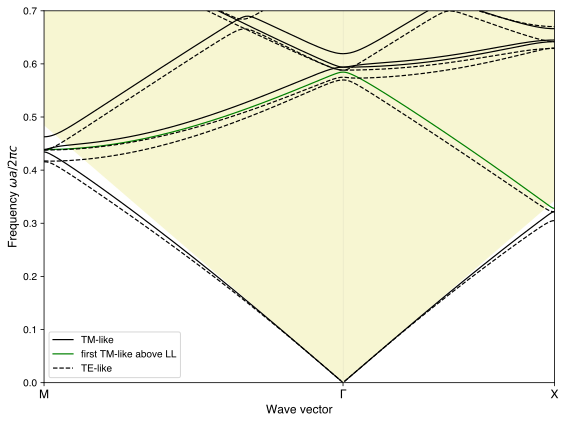

In [15]:
fig, ax = plt.subplots(1, figsize=(8, 6))
ax.fill_between(x_plot, light_line, np.nanmax(
    freqs), facecolor='#F0EFA6', alpha=0.5)

tm_labeled = False
te_labeled = False

for band_index, band in enumerate(visible_tm_like_bands):
    if band_index == 1:
        ax.plot(x_plot, band, color='g', linestyle='-',
                lw=1.2, label='first TM-like above LL')
    else:
        label = 'TM-like' if not tm_labeled else None
        tm_labeled = True
        ax.plot(x_plot, band, color='k', linestyle='-', lw=1.2, label=label)

for band in visible_te_like_bands:
    label = 'TE-like' if not te_labeled else None
    te_labeled = True
    ax.plot(x_plot, band, color='k', linestyle='--', lw=1.2, label=label)

ax.set_ylim([0, 0.70])
ax.set_xlim([x_plot[0], x_plot[-1]])

tick_locs = [x_plot[0], x_plot[gamma_index], x_plot[-1]]
tick_labs = ["M", r"$\Gamma$", "X"]
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=12)
ax.set_xlabel("Wave vector", size=12)
ax.set_ylabel(r"Frequency $\omega a/2\pi c$", size=12)
ax.legend(loc='best')
for xpos in tick_locs:
    ax.axvline(xpos, color='gray', lw=0.1)

fig.tight_layout()